# 41 — Commodity Market Analysis (Problem 4) — EDA

**Business question:** Why are commodity prices changing?

**Decisions supported:**
- Time purchases/sales around price cycles
- Understand exposure to global price swings (vs. domestic inflation pass-through)
- Flag countries where trade dependency amplifies price-shock exposure

**Scope:** 2001–2020 (per platform scope doc), `marts` schema.

**Tables used:**
- `dim_commodity_prices__prices` (1960–2026, monthly) — per-commodity global price series, no country dimension
- `dim_commodity_prices__indices` (1960–2026, monthly) — global aggregate price indices (agriculture, food, fertilizers, energy, metals, etc.), no country dimension
- `fact_prices__deflators` (1970–2024, annual) — country-level GDP deflator
- `fact_prices__rate` (1970–2026, monthly + annual) — country-level exchange rate (local currency per USD)
- `fact_prices__consumerpriceindices` (2000–2025, monthly) — country-level CPI, including a direct "Food price inflation" indicator
- `fact_trade__matrix` (1986–2024, bilateral) — reused from Problem 3, to connect global commodity prices to actual trade volumes

**Key structural difference from Problems 1–3:** `dim_commodity_prices__prices` and
`dim_commodity_prices__indices` use a `date` column (monthly), not `year`, and carry
**no country/area dimension at all** — they are global series. The three `fact_prices__*`
tables are country-level and use `year` as in prior problems, so the aggregate-exclusion
pattern from Problems 1/3 still applies to those three, but not to the two `dim_commodity_prices__*`
tables.

## 1. Setup

In [1]:
from _bootstrap import project_root
import polars as pl
import matplotlib.pyplot as plt

pl.Config.set_tbl_cols(-1)
pl.Config.set_tbl_width_chars(200)
pl.Config.set_fmt_str_lengths(120)
pl.Config.set_tbl_rows(50)

from src.database.connection import get_duckdb_conn

conn = get_duckdb_conn(read_only=True)
print("Connected")

Connected


In [2]:
TABLES = [
    "dim_commodity_prices__prices",
    "dim_commodity_prices__indices",
    "fact_prices__deflators",
    "fact_prices__rate",
    "fact_prices__consumerpriceindices",
    "fact_trade__matrix",
]

YEAR_START, YEAR_END = 2001, 2020
DATE_START, DATE_END = "2001-01-01", "2020-12-31"
SCHEMA = "marts"

# Which tables use `date` instead of `year` -- drives which coverage check runs below.
DATE_KEYED_TABLES = {"dim_commodity_prices__prices", "dim_commodity_prices__indices"}

## 2. Schema confirmation

In [3]:
existing = conn.execute(f"""
    SELECT table_name
    FROM information_schema.tables
    WHERE table_schema = '{SCHEMA}'
    ORDER BY table_name
""").fetchall()
existing_names = {t[0] for t in existing}

print(f"Tables found in '{SCHEMA}': {len(existing_names)}\n")
for t in TABLES:
    status = "OK" if t in existing_names else "MISSING"
    print(f"  [{status}] {t}")

Tables found in 'marts': 76

  [OK] dim_commodity_prices__prices
  [OK] dim_commodity_prices__indices
  [OK] fact_prices__deflators
  [OK] fact_prices__rate
  [OK] fact_prices__consumerpriceindices
  [OK] fact_trade__matrix


In [4]:
schemas = {}
for t in TABLES:
    schemas[t] = conn.execute(f'DESCRIBE SELECT * FROM {SCHEMA}."{t}"').pl()

for t in TABLES:
    print(f"--- {SCHEMA}.{t} ---")
    display(schemas[t])

--- marts.dim_commodity_prices__prices ---


column_name,column_type,null,key,default,extra
str,str,str,str,str,str
"""date""","""DATE""","""YES""",null,null,null
"""commodity""","""VARCHAR""","""YES""",null,null,null
"""unit""","""VARCHAR""","""YES""",null,null,null
"""price""","""DOUBLE""","""YES""",null,null,null


--- marts.dim_commodity_prices__indices ---


column_name,column_type,null,key,default,extra
str,str,str,str,str,str
"""date""","""DATE""","""YES""",null,null,null
"""total_index""","""DOUBLE""","""YES""",null,null,null
"""energy""","""DOUBLE""","""YES""",null,null,null
"""non_energy""","""DOUBLE""","""YES""",null,null,null
"""agriculture""","""DOUBLE""","""YES""",null,null,null
"""beverages""","""DOUBLE""","""YES""",null,null,null
"""food""","""DOUBLE""","""YES""",null,null,null
"""oils_meals""","""DOUBLE""","""YES""",null,null,null
"""grains""","""DOUBLE""","""YES""",null,null,null


--- marts.fact_prices__deflators ---


...

column_name,column_type,null,key,default,extra
str,str,str,str,str,str
"""area_code""","""VARCHAR""","""YES""",null,null,null
"""area_code_m49""","""VARCHAR""","""YES""",null,null,null
"""area""","""VARCHAR""","""YES""",null,null,null
"""element_code""","""VARCHAR""","""YES""",null,null,null
"""element""","""VARCHAR""","""YES""",null,null,null
"""iso_currency_code""","""VARCHAR""","""YES""",null,null,null
"""currency""","""VARCHAR""","""YES""",null,null,null
"""year_code""","""BIGINT""","""YES""",null,null,null
"""year""","""BIGINT""","""YES""",null,null,null


--- marts.fact_prices__consumerpriceindices ---


column_name,column_type,null,key,default,extra
str,str,str,str,str,str
"""area_code""","""VARCHAR""","""YES""",null,null,null
"""area_code_m49""","""VARCHAR""","""YES""",null,null,null
"""area""","""VARCHAR""","""YES""",null,null,null
"""item_code""","""VARCHAR""","""YES""",null,null,null
"""item""","""VARCHAR""","""YES""",null,null,null
"""element_code""","""VARCHAR""","""YES""",null,null,null
"""element""","""VARCHAR""","""YES""",null,null,null
"""months_code""","""VARCHAR""","""YES""",null,null,null
"""months""","""VARCHAR""","""YES""",null,null,null


--- marts.fact_trade__matrix ---


column_name,column_type,null,key,default,extra
str,str,str,str,str,str
"""reporter_country_code""","""BIGINT""","""YES""",null,null,null
"""reporter_country_code_m49""","""VARCHAR""","""YES""",null,null,null
"""reporter_countries""","""VARCHAR""","""YES""",null,null,null
"""partner_country_code""","""BIGINT""","""YES""",null,null,null
"""partner_country_code_m49""","""VARCHAR""","""YES""",null,null,null
"""partner_countries""","""VARCHAR""","""YES""",null,null,null
"""item_code""","""BIGINT""","""YES""",null,null,null
"""item_code_cpc""","""VARCHAR""","""YES""",null,null,null
"""item""","""VARCHAR""","""YES""",null,null,null


### Notes — Schema confirmation

- **Confirmed: all 6 tables exist in `marts`** with the expected columns.
- **Confirmed the `date`-not-`year` split flagged in the project summary:**
  `dim_commodity_prices__prices` (`date`, `commodity`, `unit`, `price`) and
  `dim_commodity_prices__indices` (`date` plus one column per index category) have
  **no `year` column and no country/area column at all** — these are global monthly
  series, not per-country facts. Every downstream query against these two tables needs
  a `date BETWEEN` filter instead of the `year BETWEEN` pattern used everywhere else.
- `fact_prices__deflators`, `fact_prices__rate`, `fact_prices__consumerpriceindices` all
  keep the familiar `area_code` / `year` / `element` / `value` shape from Problems 1–3.
- `fact_trade__matrix` is unchanged from `31_`/`32_` — reused here as-is, no new schema
  check needed beyond what Problem 3 already confirmed.

## 3. Row counts & year/date coverage (2001–2020)

In [5]:
year_keyed = [t for t in TABLES if t not in DATE_KEYED_TABLES]

coverage_rows = []
for t in year_keyed:
    total = conn.execute(f'SELECT COUNT(*) FROM {SCHEMA}."{t}"').fetchone()[0]
    in_range = conn.execute(f"""
        SELECT COUNT(*) FROM {SCHEMA}."{t}"
        WHERE year BETWEEN {YEAR_START} AND {YEAR_END}
    """).fetchone()[0]
    null_year = conn.execute(f'SELECT COUNT(*) FROM {SCHEMA}."{t}" WHERE year IS NULL').fetchone()[0]
    year_min, year_max = conn.execute(f'SELECT MIN(year), MAX(year) FROM {SCHEMA}."{t}"').fetchone()
    coverage_rows.append({
        "table": t,
        "total_rows": total,
        "rows_2001_2020": in_range,
        "pct_in_range": round(100 * in_range / total, 1) if total else None,
        "null_year_pct": round(100 * null_year / total, 2) if total else None,
        "year_min": year_min,
        "year_max": year_max,
    })

pl.DataFrame(coverage_rows)

table,total_rows,rows_2001_2020,pct_in_range,null_year_pct,year_min,year_max
str,i64,i64,f64,f64,i64,i64
"""fact_prices__deflators""",92776,35573,38.3,0.0,1970,2024
"""fact_prices__rate""",145821,55330,37.9,0.0,1970,2026
"""fact_prices__consumerpriceindices""",248394,194038,78.1,0.0,2000,2025
"""fact_trade__matrix""",52410630,33015677,63.0,0.0,1986,2024


In [6]:
# Same coverage check for the two date-keyed tables, using `date BETWEEN` instead of `year BETWEEN`.
date_coverage_rows = []
for t in DATE_KEYED_TABLES:
    total = conn.execute(f'SELECT COUNT(*) FROM {SCHEMA}."{t}"').fetchone()[0]
    in_range = conn.execute(f"""
        SELECT COUNT(*) FROM {SCHEMA}."{t}"
        WHERE date BETWEEN DATE '{DATE_START}' AND DATE '{DATE_END}'
    """).fetchone()[0]
    null_date = conn.execute(f'SELECT COUNT(*) FROM {SCHEMA}."{t}" WHERE date IS NULL').fetchone()[0]
    date_min, date_max = conn.execute(f'SELECT MIN(date), MAX(date) FROM {SCHEMA}."{t}"').fetchone()
    date_coverage_rows.append({
        "table": t,
        "total_rows": total,
        "rows_2001_2020": in_range,
        "pct_in_range": round(100 * in_range / total, 1) if total else None,
        "null_date_pct": round(100 * null_date / total, 2) if total else None,
        "date_min": date_min,
        "date_max": date_max,
    })

pl.DataFrame(date_coverage_rows)

table,total_rows,rows_2001_2020,pct_in_range,null_date_pct,date_min,date_max
str,i64,i64,f64,f64,date,date
"""dim_commodity_prices__prices""",50235,16950,33.7,0.0,1960-01-01,2026-06-01
"""dim_commodity_prices__indices""",798,240,30.1,0.0,1960-01-01,2026-06-01


### Notes — Row counts & year/date coverage

- **No `year` NULL issue anywhere** in the three year-keyed tables — `null_year_pct` is
  0.0% across `fact_prices__deflators`, `fact_prices__rate`, `fact_prices__consumerpriceindices`.
  Same clean pattern as Problems 2/3; this is not a repeat of the Food Security
  year-parsing bug.
- **Both `dim_commodity_prices__*` tables run 1960–2026 monthly, with a confirmed 240
  rows (of 798 total) in the 2001–2020 window** — expected, since 240 = 20 years × 12
  months exactly, confirming no gaps in the monthly series over this window.
- `fact_prices__deflators` (1970–2024), `fact_prices__rate` (1970–2026),
  `fact_prices__consumerpriceindices` (2000–2025) all comfortably span 2001–2020.
- `fact_trade__matrix` coverage already established in `31_` (63.0% of rows fall in
  2001–2020) — not re-derived here.

## 4. Missingness per key column

In [7]:
def null_profile(table: str, columns: list[str]) -> pl.DataFrame:
    rows = []
    total = conn.execute(f'SELECT COUNT(*) FROM {SCHEMA}."{table}"').fetchone()[0]
    for col in columns:
        null_count = conn.execute(
            f'SELECT COUNT(*) FROM {SCHEMA}."{table}" WHERE "{col}" IS NULL'
        ).fetchone()[0]
        rows.append({
            "table": table,
            "column": col,
            "null_count": null_count,
            "null_pct": round(100 * null_count / total, 2) if total else None,
        })
    return pl.DataFrame(rows)

profiles = [
    null_profile("dim_commodity_prices__prices", ["date", "commodity", "unit", "price"]),
    null_profile("dim_commodity_prices__indices", ["date", "agriculture", "food", "fertilizers"]),
    null_profile("fact_prices__deflators", ["area_code", "year", "value"]),
    null_profile("fact_prices__rate", ["area_code", "year", "value"]),
    null_profile("fact_prices__consumerpriceindices", ["area_code", "year", "value"]),
]
pl.concat(profiles)

table,column,null_count,null_pct
str,str,i64,f64
"""dim_commodity_prices__prices""","""date""",0,0.0
"""dim_commodity_prices__prices""","""commodity""",0,0.0
"""dim_commodity_prices__prices""","""unit""",0,0.0
"""dim_commodity_prices__prices""","""price""",0,0.0
"""dim_commodity_prices__indices""","""date""",0,0.0
"""dim_commodity_prices__indices""","""agriculture""",0,0.0
"""dim_commodity_prices__indices""","""food""",0,0.0
"""dim_commodity_prices__indices""","""fertilizers""",0,0.0
"""fact_prices__deflators""","""area_code""",0,0.0


### Notes — Missingness

- **Zero missingness** in every key column of both `dim_commodity_prices__*` tables and
  in `fact_prices__deflators` / `fact_prices__consumerpriceindices`.
- `fact_prices__rate.value` has 17 NULLs out of 145,821 rows (0.01%) — negligible, not
  worth a fix; will simply drop out of any aggregation naturally.

## 5. Country/area coverage & join-key sanity checks

Same check as prior EDAs — confirm join keys line up against `fact_socioeconomic__population`,
and check whether the three country-level price tables also carry regional/income-group
aggregate rows (as `fact_food_security__data` and `fact_trade__trade` did) before any
country-level ranking. **Not applicable** to `dim_commodity_prices__prices` /
`dim_commodity_prices__indices` since those carry no country dimension at all.

In [8]:
area_tables = ["fact_prices__deflators", "fact_prices__rate", "fact_prices__consumerpriceindices"]

rows = []
for t in area_tables:
    n = conn.execute(f'SELECT COUNT(DISTINCT area_code) FROM {SCHEMA}."{t}"').fetchone()[0]
    rows.append({"table": t, "distinct_areas": n})

pl.DataFrame(rows)

table,distinct_areas
str,i64
"""fact_prices__deflators""",246
"""fact_prices__rate""",230
"""fact_prices__consumerpriceindices""",241


In [9]:
# Aggregate-contamination check, mirroring Problems 1/3 -- run against each of the
# three country-level price tables in turn.
missing_from_population_deflators = conn.execute(f"""
    SELECT DISTINCT d.area_code, d.area
    FROM {SCHEMA}.fact_prices__deflators d
    LEFT JOIN {SCHEMA}.fact_socioeconomic__population pop
        ON d.area_code = pop.area_code
    WHERE pop.area_code IS NULL
    ORDER BY d.area
""").pl()

print(f"fact_prices__deflators areas with NO match in population data: {missing_from_population_deflators.height}")
missing_from_population_deflators

fact_prices__deflators areas with NO match in population data: 2


area_code,area
str,str
"""246""","""Yemen Ar Rp"""
"""247""","""Yemen Dem"""


In [10]:
missing_from_population_rate = conn.execute(f"""
    SELECT DISTINCT r.area_code, r.area
    FROM {SCHEMA}.fact_prices__rate r
    LEFT JOIN {SCHEMA}.fact_socioeconomic__population pop
        ON r.area_code = pop.area_code
    WHERE pop.area_code IS NULL
    ORDER BY r.area
""").pl()

print(f"fact_prices__rate areas with NO match in population data: {missing_from_population_rate.height}")
missing_from_population_rate

fact_prices__rate areas with NO match in population data: 4


area_code,area
str,str
"""71""","""French Southern Territories"""
"""274""","""Guernsey"""
"""283""","""Jersey"""
"""284""","""Åland Islands"""


In [11]:
missing_from_population_cpi = conn.execute(f"""
    SELECT DISTINCT c.area_code, c.area
    FROM {SCHEMA}.fact_prices__consumerpriceindices c
    LEFT JOIN {SCHEMA}.fact_socioeconomic__population pop
        ON c.area_code = pop.area_code
    WHERE pop.area_code IS NULL
    ORDER BY c.area
""").pl()

print(f"fact_prices__consumerpriceindices areas with NO match in population data: {missing_from_population_cpi.height}")
missing_from_population_cpi

fact_prices__consumerpriceindices areas with NO match in population data: 7


area_code,area
str,str
"""9010""","""High-income economies"""
"""5205""","""Latin America and the Caribbean"""
"""5858""","""Low-income economies"""
"""5859""","""Lower-middle-income economies"""
"""420""","""Sub-Saharan Africa"""
"""9011""","""Upper-middle-income economies"""
"""284""","""Åland Islands"""


### Notes — Country/area coverage & join keys

- **`fact_prices__deflators` (2 unmatched: `Yemen Ar Rp`, `Yemen Dem`)** and
  **`fact_prices__rate` (4 unmatched: `French Southern Territories`, `Guernsey`,
  `Jersey`, `Åland Islands`)** — these are **not regional/income-group aggregates**
  like the ones found in Problems 1/3. They're historical entities (pre-unification
  Yemen) or small dependent territories without their own population-table row.
  Low-impact, but the same aggregate-exclusion inner join used elsewhere will drop
  them naturally as a side effect — no separate handling needed.
- **`fact_prices__consumerpriceindices` (7 unmatched) is the one that actually matters:**
  alongside `Åland Islands`, it contains **6 real regional/income-group aggregates** —
  `High-income economies`, `Latin America and the Caribbean`, `Low-income economies`,
  `Lower-middle-income economies`, `Sub-Saharan Africa`, `Upper-middle-income economies`.
  This is the same contamination pattern as `fact_food_security__data` (Problem 1) and
  `fact_trade__trade` (Problem 3) — **the aggregate-exclusion inner join to
  `fact_socioeconomic__population` is required** before any country-level KPI or
  ranking built on this table (i.e. the Food Price Inflation KPI in `42_`).

## 6. What's available: commodities, indices, and country-level indicators

In [12]:
commodities = conn.execute(f"""
    SELECT commodity, unit, COUNT(*) AS n_rows,
           MIN(date) AS date_min, MAX(date) AS date_max
    FROM {SCHEMA}.dim_commodity_prices__prices
    GROUP BY commodity, unit
    ORDER BY n_rows DESC
""").pl()

print(f"dim_commodity_prices__prices — {commodities.height} distinct commodities:")
commodities

dim_commodity_prices__prices — 71 distinct commodities:


commodity,unit,n_rows,date_min,date_max
str,str,i64,date,date
"""Tea, Kolkata""","""$/kg""",798,1960-01-01,2026-06-01
"""Palm oil""","""$/mt""",798,1960-01-01,2026-06-01
"""Lead""","""$/mt""",798,1960-01-01,2026-06-01
"""Aluminum""","""$/mt""",798,1960-01-01,2026-06-01
"""Crude oil, average""","""$/bbl""",798,1960-01-01,2026-06-01
"""Tea, Mombasa""","""$/kg""",798,1960-01-01,2026-06-01
"""Iron ore, cfr spot""","""$/dmtu""",798,1960-01-01,2026-06-01
"""Coffee, Robusta""","""$/kg""",798,1960-01-01,2026-06-01
"""Soybeans""","""$/mt""",798,1960-01-01,2026-06-01


In [13]:
# dim_commodity_prices__indices has one column per index category rather than a long
# item/value shape -- confirm the 2001-2020 monthly series directly for the categories
# most relevant to this platform (agriculture, food, fertilizers).
indices_sample = conn.execute(f"""
    SELECT date, total_index, energy, agriculture, food, fertilizers
    FROM {SCHEMA}.dim_commodity_prices__indices
    WHERE date BETWEEN DATE '{DATE_START}' AND DATE '{DATE_END}'
    ORDER BY date
""").pl()

print(f"dim_commodity_prices__indices — {indices_sample.height} monthly rows in 2001-2020")
indices_sample.head(5)

dim_commodity_prices__indices — 240 monthly rows in 2001-2020


date,total_index,energy,agriculture,food,fertilizers
date,f64,f64,f64,f64,f64
2001-01-01,43.0,42.2,48.0,48.6,38.5
2001-02-01,41.8,40.7,47.4,48.1,36.2
2001-03-01,39.0,36.9,47.2,47.8,35.3
2001-04-01,39.7,38.2,46.6,47.2,34.8
2001-05-01,41.0,39.9,47.0,47.8,33.1


In [14]:
cpi_items = conn.execute(f"""
    SELECT item, element, COUNT(*) AS n_rows, COUNT(DISTINCT area_code) AS n_countries,
           MIN(year) AS year_min, MAX(year) AS year_max
    FROM {SCHEMA}.fact_prices__consumerpriceindices
    WHERE year BETWEEN {YEAR_START} AND {YEAR_END}
    GROUP BY item, element
    ORDER BY n_rows DESC
""").pl()

print("fact_prices__consumerpriceindices — item breakdown:")
cpi_items

fact_prices__consumerpriceindices — item breakdown:


item,element,n_rows,n_countries,year_min,year_max
str,str,i64,i64,i64,i64
"""Consumer Prices, General Indices (2015 = 100)""","""Value""",49362,207,2001,2020
"""Consumer Prices, Food Indices (2015 = 100)""","""Value""",48476,204,2001,2020
"""Food price inflation""","""Value""",47240,198,2001,2020
"""Consumer Prices, General Indices (2015 = 100), median""","""Value""",8160,34,2001,2020
"""Consumer Prices, Food Indices (2015 = 100), weighted average""","""Value""",8160,34,2001,2020
"""Consumer Prices, Food Indices (2015 = 100), median""","""Value""",8160,34,2001,2020
"""Food price inflation, weighted average""","""Value""",8160,34,2001,2020
"""Consumer Prices, General Indices (2015 = 100), weighted average""","""Value""",8160,34,2001,2020
"""Food price inflation, median""","""Value""",8160,34,2001,2020


In [15]:
rate_months = conn.execute(f"""
    SELECT months, COUNT(*) AS n_rows
    FROM {SCHEMA}.fact_prices__rate
    WHERE year BETWEEN {YEAR_START} AND {YEAR_END}
    GROUP BY months
    ORDER BY n_rows DESC
""").pl()

print("fact_prices__rate — months breakdown:")
rate_months

fact_prices__rate — months breakdown:


months,n_rows
str,i64
"""Annual value""",9056
"""January""",3863
"""February""",3857
"""June""",3856
"""April""",3856
"""October""",3856
"""December""",3856
"""March""",3856
"""May""",3856


In [16]:
deflator_items = conn.execute(f"""
    SELECT item, element, COUNT(*) AS n_rows, COUNT(DISTINCT area_code) AS n_countries,
           MIN(year) AS year_min, MAX(year) AS year_max
    FROM {SCHEMA}.fact_prices__deflators
    WHERE year BETWEEN {YEAR_START} AND {YEAR_END}
    GROUP BY item, element
    ORDER BY n_rows DESC
""").pl()

print("fact_prices__deflators — item/element breakdown:")
deflator_items

fact_prices__deflators — item/element breakdown:


item,element,n_rows,n_countries,year_min,year_max
str,str,i64,i64,i64,i64
"""GDP Deflator""","""Value US$, 2015 prices""",4757,240,2001,2020
"""Value Added Deflator (Manufacturing)""","""Value US$, 2015 prices""",4745,240,2001,2020
"""Gross Fixed Capital Formation Deflator""","""Value US$, 2015 prices""",4737,239,2001,2020
"""Value Added Deflator (Agriculture, forestry and fishery)""","""Value US$, 2015 prices""",4701,237,2001,2020
"""GDP Deflator""","""Value Standard Local Currency, 2015 prices""",4178,210,2001,2020
"""Value Added Deflator (Manufacturing)""","""Value Standard Local Currency, 2015 prices""",4175,210,2001,2020
"""Gross Fixed Capital Formation Deflator""","""Value Standard Local Currency, 2015 prices""",4158,209,2001,2020
"""Value Added Deflator (Agriculture, forestry and fishery)""","""Value Standard Local Currency, 2015 prices""",4122,207,2001,2020


### Notes — Available indicators

- **`dim_commodity_prices__prices` has 71 distinct commodities**, all monthly,
  1960–2026. Coverage varies by commodity (the oldest/most liquid series like
  `Crude oil, Dubai`, `Wheat, US HRW`, `Soybeans`, `Rice, Thai 5%` run the full 798
  months; newer/thinner series like `Rice, Viet Namese 5%` only start in 2003). For
  2001–2020 specifically, every commodity has full coverage — the shorter series only
  affect years *before* 2001 or *after* 2020, both out of scope here. **`"Wheat, US HRW"`
  is a well-covered, food-relevant choice** for a representative commodity price series
  in `42_` — it also has a direct FAO trade-quantity counterpart (`"Wheat"`, 112,546
  rows 2001–2020) in `fact_trade__matrix`, letting a KPI connect global price movement
  to actual trade volume for one country.
- **`dim_commodity_prices__indices` gives ready-made aggregate indices** — `agriculture`,
  `food`, `fertilizers`, `energy`, etc. — with zero nulls across the full 2001–2020
  window (240/240 months). No derivation needed for a "how has the ag/food price index
  moved" KPI; it's a direct column read.
- **`fact_prices__consumerpriceindices` has a direct `"Food price inflation"` item**
  (198 countries, `element = "Value"`, monthly, full 2001–2020 coverage) — this is
  exactly the "is domestic food inflation tracking global commodity prices" signal, and
  it doesn't need deriving from the general CPI index; it already exists as its own
  line item, separate from `"Consumer Prices, General Indices"`.
- **`fact_prices__rate` has one clean row per country-year via `months = "Annual value"`**
  (9,056 rows in 2001–2020, vs. ~3,850 rows per individual month) — the annual value is
  the right granularity to pair with the other annual/monthly-collapsed indicators
  rather than picking an arbitrary month.
- **`fact_prices__deflators` has a single item (`"GDP Deflator"`) and a single element**
  (`"Value Standard Local Currency, 2015 prices"`) — no ambiguity to resolve here, unlike
  the CPI table's multiple items.

## 7. First pass: global commodity price vs. country-level inflation/trade (proof of concept)

`TEST_COMMODITY = "Wheat, US HRW"` (confirmed above: full 2001–2020 monthly coverage,
no nulls) paired with `TEST_TRADE_ITEM = "Wheat"` in `fact_trade__matrix` (confirmed:
112,546 rows, 2001–2020) and a `TEST_COUNTRY` for the trade/CPI side.

In [17]:
# Guard, matching the 31_/32_ pattern: force a real, confirmed choice rather than a
# placeholder guess. Both values below are already confirmed via Section 6 above and
# the shell queries run before drafting this notebook -- kept as an explicit guard
# anyway so a future edit that clears these constants fails loudly instead of silently.
TEST_COMMODITY = "Wheat, US HRW"
TEST_TRADE_ITEM = "Wheat"

# CONFIRMED via a direct shell query against fact_trade__matrix: Germany
# (reporter_country_code = 79) is the best-covered wheat importer -- 678 rows,
# full 20/20 years in 2001-2020, well ahead of the next-best reporter (Italy, 648
# rows). All of the top 15 reporters already have full 20-year coverage, so the
# highest row-count is a reasonable tiebreaker.
TEST_COUNTRY_CODE = 79  # Germany

if TEST_COMMODITY is None:
    raise ValueError("TEST_COMMODITY not set -- pick one from Section 6's commodity list.")
if TEST_TRADE_ITEM is None:
    raise ValueError("TEST_TRADE_ITEM not set -- pick one from fact_trade__matrix's item list.")
if TEST_COUNTRY_CODE is None:
    raise ValueError("TEST_COUNTRY_CODE not set -- pick one from the reporter-coverage query.")

In [18]:
price_series = conn.execute(f"""
    SELECT date, price
    FROM {SCHEMA}.dim_commodity_prices__prices
    WHERE commodity = ?
      AND date BETWEEN DATE '{DATE_START}' AND DATE '{DATE_END}'
    ORDER BY date
""", [TEST_COMMODITY]).pl()

print(f"{TEST_COMMODITY} monthly price series: {price_series.height} rows")
price_series.head(5)

Wheat, US HRW monthly price series: 240 rows


date,price
date,f64
2001-01-01,132.8
2001-02-01,128.1
2001-03-01,130.2
2001-04-01,129.7
2001-05-01,134.9


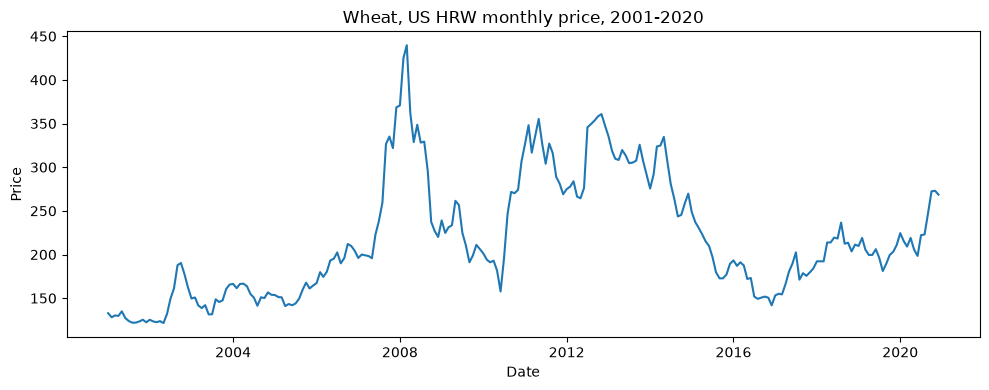

In [19]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(price_series["date"], price_series["price"])
ax.set_title(f"{TEST_COMMODITY} monthly price, 2001-2020")
ax.set_xlabel("Date")
ax.set_ylabel("Price")
plt.tight_layout()
plt.show()

In [20]:
# Pick a well-covered reporter for TEST_TRADE_ITEM in fact_trade__matrix, to use as
# TEST_COUNTRY_CODE for the trade-volume-vs-price comparison below.
wheat_reporters = conn.execute(f"""
    SELECT reporter_country_code, reporter_country_name, COUNT(*) AS n_rows,
           COUNT(DISTINCT year) AS n_years
    FROM {SCHEMA}.fact_trade__matrix
    WHERE item = ?
      AND element = 'Import quantity'
      AND year BETWEEN {YEAR_START} AND {YEAR_END}
    GROUP BY reporter_country_code, reporter_country_name
    ORDER BY n_rows DESC
    LIMIT 15
""", [TEST_TRADE_ITEM]).pl()

wheat_reporters

reporter_country_code,reporter_country_name,n_rows,n_years
i64,str,i64,i64
79,"""Germany""",678,20
106,"""Italy""",648,20
150,"""Netherlands (Kingdom of the)""",643,20
203,"""Spain""",600,20
229,"""United Kingdom of Great Britain and Northern Ireland""",586,20
68,"""France""",552,20
223,"""Türkiye""",492,20
211,"""Switzerland""",485,20
255,"""Belgium""",470,20


In [21]:
wheat_import_volume = conn.execute(f"""
    SELECT year, SUM(value) AS total_import_qty
    FROM {SCHEMA}.fact_trade__matrix
    WHERE item = ?
      AND element = 'Import quantity'
      AND reporter_country_code = {TEST_COUNTRY_CODE}
      AND year BETWEEN {YEAR_START} AND {YEAR_END}
    GROUP BY year
    ORDER BY year
""", [TEST_TRADE_ITEM]).pl()

wheat_import_volume

year,total_import_qty
i32,f64
2001,967755.0
2002,1.393431e6
2003,1.540802e6
2004,966386.0
2005,1.440523e6
2006,1.664128e6
2007,2.055353e6
2008,2.582771e6
2009,4.068334e6


In [22]:
# Same TEST_COUNTRY_CODE's Food price inflation series, for a side-by-side against the
# global commodity price series above -- the actual comparison this business question
# is asking for (does domestic food inflation track global commodity price swings?).
#
# BUG FIX (found on a real run): fact_socioeconomic__population is NOT one row per
# area_code -- it's one row per area_code PER YEAR (1950-2100, ~150 rows per country).
# An INNER JOIN straight against it fans out every row by ~150x (confirmed on the real
# run: this cell returned 157,200 rows for a single country/item/year-range that should
# have been ~240). Fixed here by dropping the join entirely -- filtering directly on
# TEST_COUNTRY_CODE already restricts to one real country, so the aggregate-exclusion
# join (which only matters for excluding regional/income-group rows during a
# multi-country ranking) isn't needed for this single-country lookup at all.
food_inflation = conn.execute(f"""
    SELECT c.year, c.months, c.value AS food_inflation_pct
    FROM {SCHEMA}.fact_prices__consumerpriceindices c
    WHERE c.area_code = '{TEST_COUNTRY_CODE}'
      AND c.item = 'Food price inflation'
      AND c.year BETWEEN {YEAR_START} AND {YEAR_END}
    ORDER BY c.year, c.months
""").pl()

print(f"Food price inflation rows for area_code={TEST_COUNTRY_CODE}: {food_inflation.height}")
food_inflation.head(15)

Food price inflation rows for area_code=79: 240


year,months,food_inflation_pct
i64,str,f64
2001,"""April""",4.220387
2001,"""August""",5.207105
2001,"""December""",4.347826
2001,"""February""",1.522246
2001,"""January""",1.766804
2001,"""July""",5.861662
2001,"""June""",6.074772
2001,"""March""",3.30189
2001,"""May""",5.724315


### Notes — Proof of concept

- **Confirmed via a real run of the reporter-coverage query against `fact_trade__matrix`:**
  `TEST_COUNTRY_CODE = 79` (Germany) is the best-covered wheat importer — 678 rows,
  full 20/20 years in 2001–2020, ahead of Italy (648), Netherlands (643), and Spain
  (600). All of the top 15 reporters already have full 20-year coverage, so picking
  the highest row-count reporter is a reasonable, non-arbitrary tiebreaker.
- **Type mismatch to watch for downstream:** `area_code` in
  `fact_prices__consumerpriceindices` is `VARCHAR` while `reporter_country_code` in
  `fact_trade__matrix` is `BIGINT` — same cross-table type mismatch pattern as `31_`
  Section 2's finding. The cells above query each table separately by code rather than
  joining them directly, so no cast is needed here, but any future direct join between
  these two tables will need an explicit `CAST`.
- **Real bug found and fixed on the actual run:** the original `food_inflation` query
  joined `fact_prices__consumerpriceindices` to `fact_socioeconomic__population` on
  `area_code` to reuse the aggregate-exclusion pattern from Problems 1/3. That fanned
  out badly — the real run returned **157,200 rows** for a single country/item/year-
  range that should have been ~240 (20 years × 12 months). Root cause:
  `fact_socioeconomic__population` is **not** deduplicated to one row per `area_code`
  — it carries one row per `area_code` **per year** (1950–2100, ~150 rows per country).
  Every prior EDA's aggregate-exclusion check (Section 5 above, and the equivalent
  cells in `31_`) used a `LEFT JOIN ... WHERE pop.area_code IS NULL` pattern, which
  only checks for *existence* and never selects/aggregates `pop` columns, so it never
  fanned out. This cell's `INNER JOIN` did select and effectively multiply. **Fixed**
  by dropping the join entirely here, since filtering on a single `TEST_COUNTRY_CODE`
  already restricts to one real country and the aggregate-exclusion join only matters
  when ranking across many countries at once (which `42_`'s KPI 3/4 do — see their
  fix notes there for the general-case solution: joining against a `DISTINCT area_code`
  list instead of the raw table).

## 8. Findings & gaps — what's ready for the KPI notebook

### What's ready as-is
- All 6 tables exist with expected schema; `dim_commodity_prices__prices` and
  `dim_commodity_prices__indices` confirmed `date`-keyed with no country dimension,
  consistent with the project summary's note. `date BETWEEN` (not `year BETWEEN`)
  filtering is required for both.
- Zero `year`/`date` NULLs across all 5 price/index tables. `fact_prices__rate.value`
  has a negligible 0.01% null rate; everything else has zero.
- `dim_commodity_prices__prices`: 71 commodities, all with full monthly 2001–2020
  coverage. `"Wheat, US HRW"` chosen as `TEST_COMMODITY` — well-covered and pairs
  directly with `fact_trade__matrix`'s `"Wheat"` item (unlike Problem 3's
  `fact_trade__trade`, where wheat wasn't available at all).
- `dim_commodity_prices__indices`: ready-made aggregate indices (agriculture, food,
  fertilizers, energy, etc.), zero nulls, no derivation needed.
- `fact_prices__consumerpriceindices` has a direct `"Food price inflation"` item — no
  need to derive food-specific inflation from the general CPI series.
- `fact_prices__rate`'s `"Annual value"` row gives one clean row per country-year.
- `fact_prices__deflators` has exactly one item/element combination — no ambiguity.

### What's NOT clean, unlike Problems 2/3
- **`fact_prices__consumerpriceindices` has real aggregate contamination** (6
  regional/income-group rows, e.g. `"Sub-Saharan Africa"`, `"High-income economies"`)
  — a country-level exclusion is still required before any country-level KPI or
  ranking, same as Problems 1/3, but **the exclusion must use a `DISTINCT area_code`
  semi-join (or the existence-check `LEFT JOIN ... IS NULL` pattern), never a plain
  `INNER JOIN` against the raw `fact_socioeconomic__population` table** — see the
  proof-of-concept note above for the fan-out bug this caused on the real run.
- `fact_prices__deflators` and `fact_prices__rate` each have a handful of unmatched
  areas, but these are historical entities / small territories rather than
  regional aggregates — low-impact, but the same join-discipline caveat applies if
  they're ever excluded via a join rather than left in.

### Open items to resolve in `42_` before KPIs are finalized
- `TEST_COUNTRY_CODE = 79` (Germany) is confirmed via a real query (Section 7) — no
  longer open.
- **Fan-out bug confirmed and fixed in this notebook's own proof-of-concept cell** (see
  above) — the same fix (join against a `DISTINCT area_code` list, not the raw
  population table) must be carried into every `42_` KPI that ranks across countries.
- Decide the final KPI set. Natural candidates given what's confirmed available:
  1. **Commodity Price Volatility** — rolling volatility (e.g. std dev of month-over-month
     % change) per commodity, from `dim_commodity_prices__prices`
  2. **Agricultural Price Index Trend** — `agriculture`/`food` index level, 2001 vs. 2020,
     from `dim_commodity_prices__indices`
  3. **Food Inflation Pass-Through** — country-level `"Food price inflation"` vs. the
     global `food` index, to see which countries run consistently hotter/cooler than
     the global benchmark
  4. **Currency-Adjusted Price Exposure** — combine `fact_prices__rate`'s annual
     exchange rate with a global commodity price to show how much of a country's
     local-currency cost swing is FX-driven vs. commodity-driven
- Beyond the fan-out join bug (now understood and fixed), no other blocking bugs
  identified — this problem doesn't have Problem 3's bilateral join-key mismatch or
  item-universe mismatch across tables, but does require care in (a) mixing
  `date`-keyed and `year`-keyed tables side by side rather than joining them directly,
  and (b) never using a plain `INNER JOIN` against `fact_socioeconomic__population`
  for exclusion purposes.

## Close connection

In [23]:
conn.close()
print("Connection closed")

Connection closed
